In [ ]:
mcp_source = "https://huggingface.co/learn/mcp-course/en/unit1/introduction"

Overview
-> MCP enables AI models to connect with external data sources, tools, and environments, allowing for the seamless transfer of information and capabilities between AI systems and the broader digital world

-> MCP offers a consistent protocol for linking AI models to external capabilities

#### Components
Just like client server relationships in HTTP, MCP has a client and a server.

- Host: The user-facing AI application that end-users interact with directly. Examples include Anthropic’s Claude Desktop
- Client: A component within the host application that manages communication with a specific MCP Server. Each Client maintains a 1:1 connection with a single Server, handling the protocol-level details of MCP communication and acting as an intermediary between the Host’s logic and the external Server.
- Server: An external program or service that exposes capabilities (Tools, Resources, Prompts) via the MCP protocol.



> A lot of content uses ‘Client’ and ‘Host’ interchangeably. Technically speaking, the host is the user-facing application, and the client is the component within the host application that manages communication with a specific MCP Server.

#### Capabilities

- Capability: Tool:- Executable functions that the AI model can invoke to perform actions or retrieve computed data. Typically relating to the use case of the application.
Ex: A tool for a weather application might be a function that returns the weather in a specific location.

- Capability: Resources:- Read-only data sources that provide context without significant computation.
Ex: A researcher assistant might have a resource for scientific papers.

- Capability: Prompts:- Pre-defined templates or workflows that guide interactions between users, AI models, and the available capabilities.

- Capability: Sampling:- Server-initiated requests for the Client/Host to perform LLM interactions, enabling recursive actions where the LLM can review generated content and make further decisions.
Ex: A writing application reviewing its own output and decides to refine it further.


#### Architectural Components of MCP

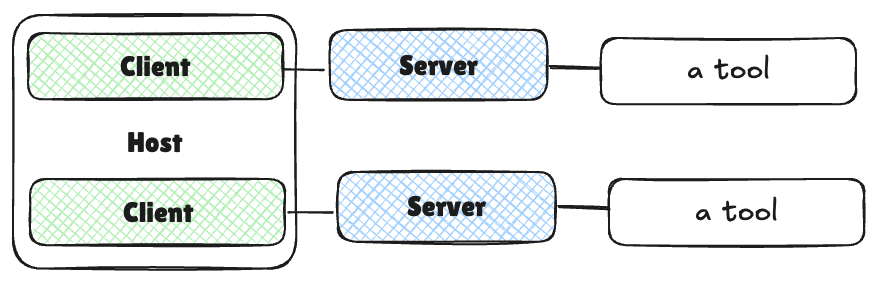

#### Communication Flow

1. User Interaction: The user interacts with the Host application, expressing an intent or query.
2. Host Processing: The Host processes the user’s input, potentially using an LLM to understand the request and determine which external capabilities might be needed.
3. Client Connection: The Host directs its Client component to connect to the appropriate Server(s).
4. Capability Discovery: The Client queries the Server to discover what capabilities (Tools, Resources, Prompts) it offers.
5. Capability Invocation: Based on the user’s needs or the LLM’s determination, the Host instructs the Client to invoke specific capabilities from the Server.
6. Server Execution: The Server executes the requested functionality and returns results to the Client.
7. Result Integration: The Client relays these results back to the Host, which incorporates them into the context for the LLM or presents them directly to the user.

Note: A key advantage of this architecture is its modularity. A single Host can connect to multiple Servers simultaneously via different Clients. New Servers can be added to the ecosystem without requiring changes to existing Hosts. Capabilities can be easily composed across different Servers.

#### The Communication Protocol

MCP defines a standardized communication protocol that enables Clients and Servers to exchange messages in a consistent, predictable way. This standardization is critical for interoperability across the community.

**JSON-RPC: The Foundation:**
At its core, MCP uses JSON-RPC 2.0 as the message format for all communication between Clients and Servers. JSON-RPC is a lightweight remote procedure call protocol encoded in JSON, which makes it:
- Human-readable and easy to debug
- Language-agnostic, supporting implementation in any programming environment
- Well-established, with clear specifications and widespread adoption


**The protocol defines three types of messages:**
1. Requests: Sent from Client to Server to initiate an operation. A Request message includes:
- A unique identifier (id)
- The method name to invoke (e.g., tools/call)
- Parameters for the method (if any)

Example: 
```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "method": "tools/call",
  "params": {
    "name": "weather",
    "arguments": {
      "location": "San Francisco"
    }
  }
}
```

2. Responses: Sent from Server to Client in reply to a Request. A Response message includes:
- The same id as the corresponding Request
- Either a result (for success) or an error (for failure)

Example Success Response:
```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "temperature": 62,
    "conditions": "Partly cloudy"
  }
}
```

Example Error Response:
```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "error": {
    "code": -32602,
    "message": "Invalid location parameter"
  }
}
```

3. Notifications: One-way messages that don’t require a response. Typically sent from Server to Client to provide updates or notifications about events
Example Notification:
```json
{
  "jsonrpc": "2.0",
  "method": "progress",
  "params": {
    "message": "Processing data...",
    "percent": 50
  }
}
````

#### Transport Mechanisms
JSON-RPC defines the message format, but MCP also specifies how these messages are transported between Clients and Servers. Two primary transport mechanisms are supported:

1. stdio (Standard Input/Output): The stdio transport is used for local communication, where the Client and Server run on the same machine:
> Use cases for this transport are local tools like file system access or running local scripts.

The main Advantages of this transport are that it’s simple, no network configuration required, and securely sandboxed by the operating system.

2. HTTP + SSE (Server-Sent Events) / Streamable HTTP: The HTTP+SSE transport is used for remote communication, where the Client and Server might be on different machines:
> Use cases for this transport are connecting to remote APIs, cloud services, or shared resources.

The main Advantages of this transport are that it works across networks, enables integration with web services, and is compatible with serverless environments.


#### Understanding MCP Capabilities

**Tools**
Tools are executable functions or actions that the AI model can invoke through the MCP protocol.

- Control: Tools are typically **model-controlled**, meaning that the AI model (LLM) decides when to call them based on the user’s request and context.
- Safety: Due to their ability to perform actions with side effects, tool execution can be dangerous. Therefore, they typically require explicit user approval.
- Use Cases: Sending messages, creating tickets, querying APIs, performing calculations.

**Resources**
Resources provide read-only access to data sources, allowing the AI model to retrieve context without executing complex logic.

- Control: Resources are application-controlled, meaning the Host application typically decides when to access them.
- Nature: They are designed for data retrieval with minimal computation, similar to GET endpoints in REST APIs.
- Safety: Since they are read-only, they typically present lower security risks than Tools.
- Use Cases: Accessing file contents, retrieving database records, reading configuration information.
Example: A resource that provides access to file contents:
```python
def read_file(file_path: str) -> str:
    """Read the contents of a file at the specified path."""
    with open(file_path, 'r') as f:
        return f.read()
```

**Prompts**
Prompts are predefined templates or workflows that guide the interaction between the user, the AI model, and the Server’s capabilities.

- Control: Prompts are user-controlled, often presented as options in the Host application’s UI.
- Purpose: They structure interactions for optimal use of available Tools and Resources.
- Selection: Users typically select a prompt before the AI model begins processing, setting context for the interaction.
- Use Cases: Common workflows, specialized task templates, guided interactions.

Example: A prompt template for generating a code review:
```python
def code_review(code: str, language: str) -> list:
    """Generate a code review for the provided code snippet."""
    return [
        {
            "role": "system",
            "content": f"You are a code reviewer examining {language} code. Provide a detailed review highlighting best practices, potential issues, and suggestions for improvement."
        },
        {
            "role": "user",
            "content": f"Please review this {language} code:\n\n```{language}\n{code}\n```"
        }
    ]
```

**Sampling**
Sampling allows Servers to request the Client (specifically, the Host application) to perform LLM interactions.

- Control: Sampling is server-initiated but requires Client/Host facilitation.
- Purpose: It enables server-driven agentic behaviors and potentially recursive or multi-step interactions.
- Safety: Like Tools, sampling operations typically require user approval.
- Use Cases: Complex multi-step tasks, autonomous agent workflows, interactive processes.

The sampling flow follows these steps:
1. Server sends a sampling/createMessage request to the client
2. Client reviews the request and can modify it
3. Client samples from an LLM
4. Client reviews the completion
5. Client returns the result to the server

**Discovery Process**
One of MCP’s key features is dynamic capability discovery. When a Client connects to a Server, it can query the available Tools, Resources, and Prompts through specific list methods:
- tools/list: Discover available Tools
- resources/list: Discover available Resources
- prompts/list: Discover available Prompts